MLD value (m): 105.0


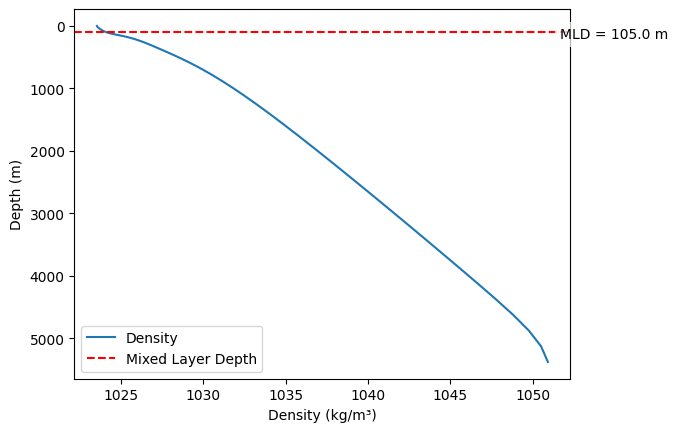

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.ndimage as nd
import gsw
from mixed_layer_cesm import open_cesm2le

# -----------------------------
# Load temperature
# -----------------------------
da_temp = open_cesm2le(
    "TEMP",
    component="ocn",
    scenario="historical",
    forcing="cmip6",
    lat=slice(20, 25),
    lon=slice(180, 185),
    members=0,
)

da_temp = da_temp.sel(time="1990-02").load()

# -----------------------------
# Load salinity
# -----------------------------
da_salt = open_cesm2le(
    "SALT",
    component="ocn",
    scenario="historical",
    forcing="cmip6",
    lat=slice(20, 25),
    lon=slice(180, 185),
    members=0,
)

da_salt = da_salt.sel(time="1990-02").load()

# -----------------------------
# Depth (convert cm → m)
# -----------------------------
z = da_temp["z_t"].values / 100.0
z = np.squeeze(z)

z_m = da_temp["z_t"] / 100.0

# -----------------------------
# Pressure
# -----------------------------
p = xr.apply_ufunc(
    gsw.p_from_z,
    -z_m,
    22.5,
    vectorize=True
)

# -----------------------------
# Conservative Temperature
# -----------------------------
CT = xr.apply_ufunc(
    gsw.CT_from_t,
    da_salt,
    da_temp,
    p,
    vectorize=True
)

# -----------------------------
# Density
# -----------------------------
rho = xr.apply_ufunc(
    gsw.rho,
    da_salt,
    CT,
    p,
    vectorize=True
)

# -----------------------------
# Horizontal mean profile
# -----------------------------
rho_prof = rho.mean(dim=["nlat", "nlon"]).squeeze()
rho_vals = rho_prof.values

# -----------------------------
# FIX 1: sort by depth
# -----------------------------
sort_idx = np.argsort(z)
z = z[sort_idx]
rho_vals = rho_vals[sort_idx]

# -----------------------------
# FIX 2: smooth density profile
# -----------------------------
rho_smooth = nd.gaussian_filter1d(rho_vals, sigma=2)

# -----------------------------
# FIX 3: compute vertical gradient (slope)
# -----------------------------
drho_dz = np.gradient(rho_smooth, z)

# -----------------------------
# MLD definition: slope threshold method
# -----------------------------
threshold = 0.01  # adjust depending on noise level

idx = np.where(np.abs(drho_dz) > threshold)[0]

if len(idx) > 0:
    mld_value = z[idx[0]]
else:
    mld_value = np.nan

# -----------------------------
# Plot density profile + MLD
# -----------------------------
plt.figure()

plt.plot(rho_smooth, z, label="Density")

if not np.isnan(mld_value):
    plt.axhline(mld_value, color="red", linestyle="--", label="Mixed Layer Depth")

if not np.isnan(mld_value):
    plt.text(
        0.98, 0.95,
        f"MLD = {mld_value:.1f} m",
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.gca().invert_yaxis()
plt.xlabel("Density (kg/m³)")
plt.ylabel("Depth (m)")
plt.legend()
plt.show()